## Multi-class logistic regression

Give the input: $X = [x_1, x_2,...,x_K]$, K is the num of features.  
linear model: $Z = Xw + b$  
softmax activation: $a_i = \frac{e^{-z_i}}{\sum_{k = 1}^K e^{-z_k}}$, mapping $a_1+a_2+...+a_K = 1$
Cross Entropy: $Loss = -\sum_{k = 1}^Ky_klog(a_k)$,  
$y = [y_1,...,y_K]$, y is a one-hot vector.  

$\frac{\partial{L}}{\partial{w}} = \frac{\partial{L}}{\partial{a}}*\frac{\partial{a}}{\partial{z}}*\frac{\partial{z}}{\partial{w}}$

![gradient calculation](./formula/multi-class-logistic-regression-gradient.JPG)  
$dw = (1/N)X^T(A-Y)$,   
where $(1/N)A-Y$ comes from $\frac{\partial{J}}{\partial{Z}} = \frac{1}{N} \sum_{i=1}^N\frac{\partial{L}}{\partial{z}} = \frac{1}{N} \sum_{i=1}^N (a-y)$, 这里的a和y都是(N,K)规模的。

$db = (1/N)\sum(A-Y)$, from the chain rule, $db = \frac{\partial{J}}{\partial{Z}}$, but since the input b(1*k) is expanded to (N*k) when make matrix product by broadcasting, finally we need to reverse b in to (1*k) through a sum.

Since the input y is a vector, need to transform it into one-hot.

数据生成完毕: X shape=(1000, 2), y shape=(1000,)
类别分布: [513 326 161]

训练集准确率: 87.00%

真实权重 W_true:
 [[ 2.  -1.   0.5]
 [-2.   2.   1. ]]
学习到的权重 model.weight:
 [[ 2.10087837 -4.20629825 -0.56739709]
 [-4.90650259  3.13416698  0.90084238]]


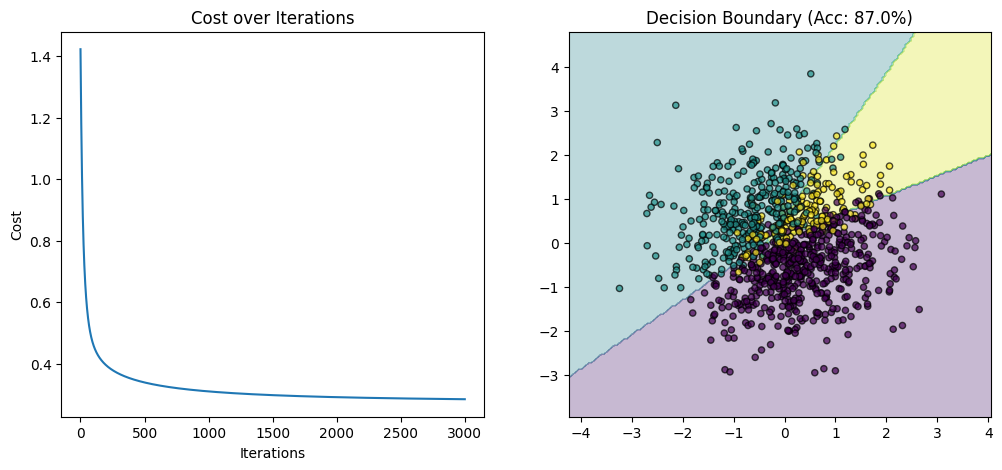

In [4]:
import numpy as np
import matplotlib.pyplot as plt

class MC_Logistic_Regression:
    """
    dimension announcement:
    X:(M, N), M is n_samples, N is n_features
    y:(1, M)
    y_one_hot:(M, K), K is n_classes
    W:(N, K)
    b:(1, K)
    z:(M, K)
    dz:(M, K)
    dw:(N, K)
    db:(1, K)
    """
    def __init__(self, learning_rate, iterations):
        self.lr = learning_rate
        self.itr = iterations

        self.weight = None
        self.bias = None

        self.costs = []

    def softmax(self, z):
        #in order to keep the numerical steablity, substract max(z) from all z.
        #exp_z = np.exp(z-np.argmax(z, axis = 1))
        exp_z = np.exp(z-np.max(z, axis = 1, keepdims=True)) # in order to use broadcast, keepdims = True
        return exp_z/np.sum(exp_z, axis = 1, keepdims=True) # the sum is N samples' class sum

    def one_hot_encode(self, y, n_classes, n_samples):
        # transfor the input y = [2, 0, 1] which means class 2 of sample 0, class 0 of sample 1, class 1 of sample 2, to one-hot array.
        y_one_hot = np.zeros((n_samples, n_classes))
        y_one_hot[np.arange(n_samples), y.flatten()] = 1 ### mapping the elements in y.flatten() to n_samples lines respectively.
        return y_one_hot

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        self.weight = np.random.randn(n_features, n_classes) ### 最开始m_features写成了n_samples
        self.bias = np.zeros(n_classes)

        y_one_hot = self.one_hot_encode(y, n_classes, n_samples)
        
        for i in range(self.itr):
            z = np.dot(X,self.weight) + self.bias # bias is broadcasted from (1,K) to (M, K)
            y_prediction = self.softmax(z)

            dz = (1/n_samples)*(y_prediction - y_one_hot)
            dw = np.dot(X.T, dz)
            db = np.sum(dz, axis = 0)

            self.weight -= self.lr * dw
            self.bias -= self.lr * db

            ### cost = -(1/n_samples)*np.sum(np.) = 
            cost = -(1/n_samples) * np.sum(y_one_hot * np.log(y_prediction + 1e-15)) ###
            self.costs.append(cost)


    def prediction(self, X):
        z = np.dot(X,self.weight) + self.bias
        return np.argmax(self.softmax(z), axis=1) ###
    

if __name__ == "__main__":
    np.random.seed(42) # 固定随机种子，保证每次结果一样

    # A. 设定世界观
    m = 1000        # 样本数
    n = 2           # 特征数 (方便画图)
    k = 3           # 类别数 (3分类)

    # B. 随机生成输入 X (1000, 2)
    X = np.random.randn(m, n)

    # C. 设定“真实”的权重和偏置 (Ground Truth)
    # 形状应该是 (2, 3) -> 2个特征对应3个类别的权重
    W_true = np.array([
        [2, -1, 0.5],  # 特征1 对 类0, 类1, 类2 的贡献
        [-2, 2, 1]     # 特征2 对 类0, 类1, 类2 的贡献
    ])
    b_true = np.array([0.5, -0.5, 0.1])

    # D. 计算真实的 Logits (Z) 并加噪声
    Z_true = np.dot(X, W_true) + b_true 
    Z_true += np.random.randn(m, k) * 0.5 # 加点噪声增加难度

    # E. 生成标签 (取概率最大的作为类别)
    def true_softmax(z):
        exp = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp / np.sum(exp, axis=1, keepdims=True)
    
    Y_probs = true_softmax(Z_true)
    y = np.argmax(Y_probs, axis=1) # 变成 [0, 1, 2, 0...]

    print(f"数据生成完毕: X shape={X.shape}, y shape={y.shape}")
    print(f"类别分布: {np.bincount(y)}")

    # === 3. 训练你的模型 ===
    model = MC_Logistic_Regression(learning_rate=0.1, iterations=3000)
    model.fit(X, y)

    # === 4. 验证结果 ===
    preds = model.prediction(X)
    acc = np.mean(preds == y)
    print(f"\n训练集准确率: {acc * 100:.2f}%")
    
    # 看看学到的权重和真实的权重差多少
    print("\n真实权重 W_true:\n", W_true)
    print("学习到的权重 model.weight:\n", model.weight)
    
    # === 5. 可视化 (Cost 曲线 + 分类边界) ===
    plt.figure(figsize=(12, 5))

    # 画 Loss
    plt.subplot(1, 2, 1)
    plt.plot(model.costs)
    plt.title("Cost over Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("Cost")

    # 画分类边界 (Decision Boundary)
    plt.subplot(1, 2, 2)
    plt.title(f"Decision Boundary (Acc: {acc*100:.1f}%)")
    
    # 生成网格点
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # 预测网格点的类别
    Z_grid = model.prediction(np.c_[xx.ravel(), yy.ravel()])
    Z_grid = Z_grid.reshape(xx.shape)
    
    # 画图
    plt.contourf(xx, yy, Z_grid, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='viridis', alpha=0.7)
    
    plt.show()